# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Load data

In [7]:
from all_gcl_manuscript.utils import restore_numpy_arrays

dataset_path = '/gpfs01/euler/data/Resources/All-GCL/database/'
all_gcl_df = pd.read_parquet(os.path.join(dataset_path, "all_GCL_table.parquet"))
all_gcl_df = restore_numpy_arrays(all_gcl_df)

Restoring numpy arrays in column: chirp_snippets
Restoring numpy arrays in column: chirp_triggertimes_snippets
Restoring numpy arrays in column: bar_snippets
Restoring numpy arrays in column: bar_triggertimes_snippets
Restoring numpy arrays in column: srf


In [ ]:
# TODO: filter dataset

In [8]:
# from gcl_analysis.dataframe import load_latest_df
# 
# all_gcl_df = load_latest_df(df_file='latest', condition_filter=True, quality_filter=True, location_filter=True,
#                          genline_filter=True, verbose=True)

In [9]:
all_gcl_df['nasal_temporal_pos_um'] = -all_gcl_df['temporal_nasal_pos_um']

'## Prepare data

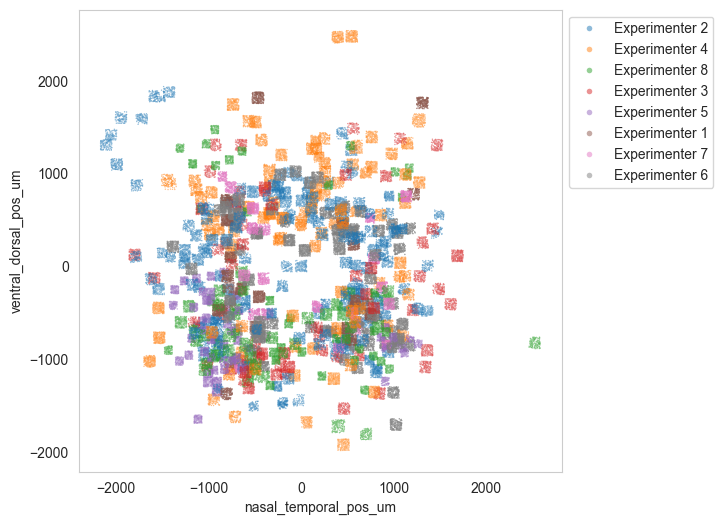

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.scatterplot(ax=ax, data=all_gcl_df, x='nasal_temporal_pos_um', y='ventral_dorsal_pos_um', hue='experimenter', s=1,
                ec='none', alpha=0.5);
ax.set_aspect('equal')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), markerscale=4)
ax.grid()
plt.show()

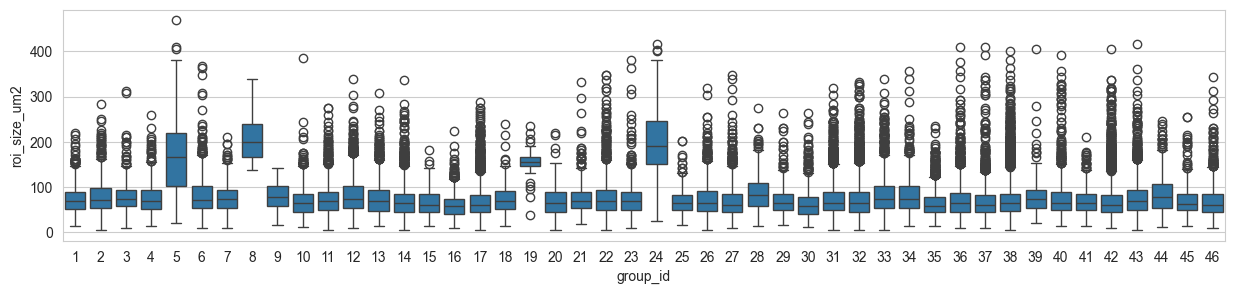

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(15, 3))
sns.boxplot(ax=ax, data=all_gcl_df, x='group_id', y='roi_size_um2');

In [13]:
df = pd.DataFrame()

x_col = 'nasal_temporal_pos_um'
y_col = 'ventral_dorsal_pos_um'

df['x'] = all_gcl_df[x_col]
df['y'] = all_gcl_df[y_col]
df['experimenter'] = all_gcl_df['experimenter']
df['group_id'] = all_gcl_df['group_id']

df.head()

,x,y,experimenter,group_id
0,627.364,-191.484,Experimenter 2,43
1,615.617,-191.326,Experimenter 2,22
2,598.565,-190.789,Experimenter 2,32
3,637.311,-193.044,Experimenter 2,42
4,666.495,-198.342,Experimenter 2,35


In [14]:
from all_gcl_manuscript.density import compute_normalized_kde_ratio

group_vals = np.asarray(df['group_id'].values)
x = np.asarray(df['x'].values)
y = np.asarray(df['y'].values)

res = compute_normalized_kde_ratio(
    x=x,
    y=y,
    groups=group_vals,
    r_max=2000,
    grid_size=51,
    bw_method=1.0,
    vthresh=np.log2(1.2),
)

xx = res["xx"]
yy = res["yy"]
outside_circle = res["outside_circle"]
dens_all = res["dens_all"]
group_ids = res["group_ids"]
norm_ratio = res["norm_ratio"]

ValueError: array must not contain infs or NaNs

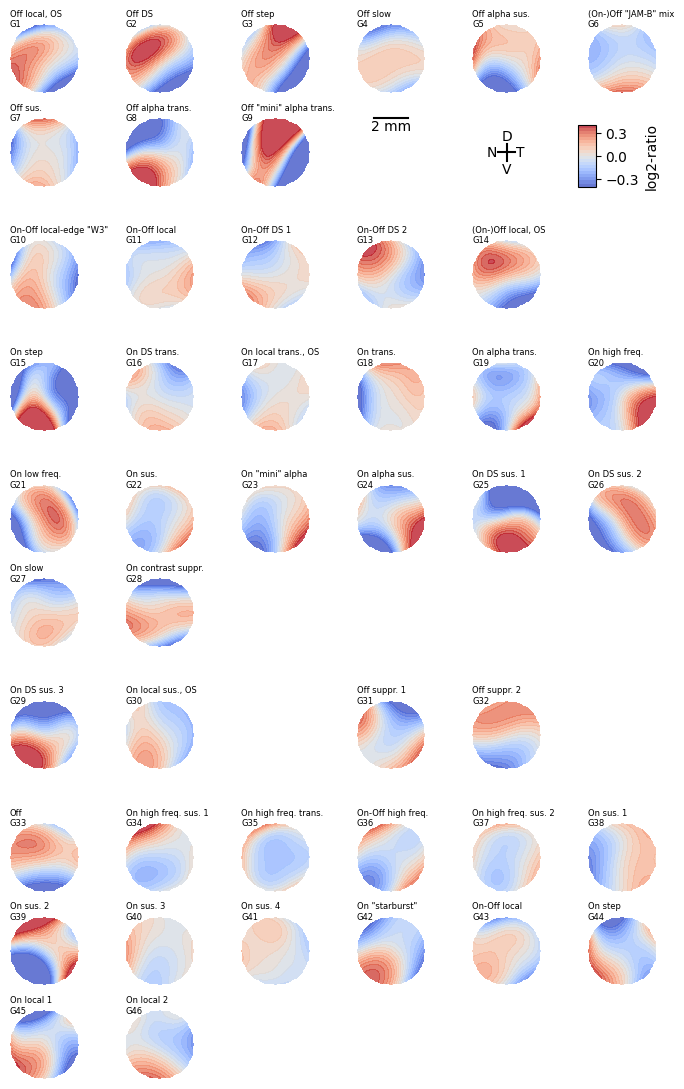

In [208]:
from gcl_analysis import baden16_utils

vmax = np.log(1.5)

cmap = 'coolwarm'
scatter_kwargs = dict(alpha=0.5, s=0.5, c="black", edgecolors="none", linewidth=0.5)
suptitle = None

n_groups = len(group_ids)

mosaic = [
    [1, 2, 3, 4, 5, 6],
    [7, 8, 9, "b", "a", "c"],
    [".", ".", ".", ".", ".", "."],
    [10, 11, 12, 13, 14, "."],
    [".", ".", ".", ".", ".", "."],
    [15, 16, 17, 18, 19, 20],
    [".", ".", ".", ".", ".", "."],
    [21, 22, 23, 24, 25, 26],
    [27, 28, ".", ".", ".", "."],
    [".", ".", ".", ".", ".", "."],
    [29, 30, ".", 31, 32, "."],
    [".", ".", ".", ".", ".", "."],
    [33, 34, 35, 36, 37, 38],
    [39, 40, 41, 42, 43, 44],
    [45, 46, ".", ".", ".", "."],
]

gap = 0.05
height_ratios = (1, 1, gap, 1, gap, 1, gap, 1, 1, gap, 1, gap, 1, 1, 1)

fig, axs = plt.subplot_mosaic(
    mosaic,
    figsize=(7, 11),
    sharex=False,
    sharey=False,
    height_ratios=height_ratios,
)

for name, ax in axs.items():
    if name not in ["c"]:
        ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal", 'box')
        ax.set_xlim(-r_max, +r_max)
        ax.set_ylim(-r_max, +r_max)

last_im = None
for gid in group_ids:
    ax = axs[gid]
    # Select rows for scatter overlay
    sel = (group_vals == gid)
    norm = np.log2(norm_ratio[gid]).copy()
    norm[outside_circle] = np.nan

    # Contours and filled
    #ax.contour(xx, yy, norm, levels=[-vthresh, +vthresh], alpha=0.8, colors=["k", "k"])
    contour = ax.contourf(
        xx,
        yy,
        np.clip(norm, -vmax, vmax),
        levels=np.linspace(-vmax, +vmax, 21),
        cmap=cmap,
        alpha=0.8,
    )
    # Points
    #ax.scatter(df.loc[sel, 'x'], df.loc[sel, 'y'], **scatter_kwargs)
    ax.set_title(f"{baden16_utils.baden_group_id_to_group_name(gid, shorten=True)}\nG{gid}", loc="left", va="top",
                 y=1.1, ha="left", fontsize=6)

#plt.colorbar(contour, ax=axs["c"], label="log2(d_g/d_all)")

tdist = 50
axs["a"].plot([-500, 500], [0, 0], c='k', dash_capstyle='butt', clip_on=False)
axs["a"].plot([0, 0], [-500, 500], c='k', dash_capstyle='butt', clip_on=False)
axs["a"].text(-500 - tdist, 0, 'N', c='k', va='center', ha='right')
axs["a"].text(+500 + tdist, 0, 'T', c='k', va='center', ha='left')
axs["a"].text(0, -500 - tdist, 'V', c='k', va='top', ha='center')
axs["a"].text(0, +500 + tdist, 'D', c='k', va='bottom', ha='center')

axs["b"].plot([-1000, 1000], [r_max, r_max], c='k', dash_capstyle='butt', clip_on=False)
axs["b"].text(0, r_max - 70, '2 mm', c='k', va='top', ha='center')

if suptitle:
    fig.suptitle(suptitle)

fig.tight_layout(h_pad=0.1, w_pad=0)

plt.colorbar(contour, ax=axs[1], cax=axs["c"], ticks=(+0.3, 0, -0.3), shrink=0.6, label='log2-ratio')
pos = axs["c"].get_position()
axs["c"].set_position([pos.x0, pos.y0, pos.width * 0.2, pos.height * 0.9])

plt.savefig('figures/celltype_density_profiles.png', dpi=300)